<a href="https://colab.research.google.com/github/sophie-gill/H1B-Visa-Dataset-Analysis/blob/main/Coding_Assignment_2_Data_Curation_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Preparation

In [ ]:
# Load all necessary packages for rest of analysis
from bs4 import BeautifulSoup
import pandas as pd
import pandas
import requests
import scipy

In [ ]:
opened_webpage = requests.get("https://www.basketball-reference.com/leagues/NBA_2023_per_game.html")
print("Webpage opened successfully...")

# Initialize a BeautifulSoup object to parse the webpage content
bs = BeautifulSoup(opened_webpage.content, "html.parser")
print("Webpage loaded and parsed successfully...")

Webpage opened successfully...
Webpage loaded and parsed successfully...


This first code chunk above makes a request to the NBA statistic webpage that I will be collecting information from and uses BeautifulSoup to parse it.

In [ ]:
# Define an empty list where the data will be kept
raw_data = []

# Find the table on the webpage
table = bs.find("table")

if table:
    # Iterate through rows in the table
    for i, row in enumerate(table.find_all('tr')):
        # Extract data from each cell in row
        cells = row.find_all('td')
        row_data = [cell.text.strip() for cell in cells]
        raw_data.append(row_data)

    print(raw_data)

[[], ['Precious Achiuwa', 'C', '23', 'TOR', '55', '12', '20.7', '3.6', '7.3', '.485', '0.5', '2.0', '.269', '3.0', '5.4', '.564', '.521', '1.6', '2.3', '.702', '1.8', '4.1', '6.0', '0.9', '0.6', '0.5', '1.1', '1.9', '9.2'], ['Steven Adams', 'C', '29', 'MEM', '42', '42', '27.0', '3.7', '6.3', '.597', '0.0', '0.0', '.000', '3.7', '6.2', '.599', '.597', '1.1', '3.1', '.364', '5.1', '6.5', '11.5', '2.3', '0.9', '1.1', '1.9', '2.3', '8.6'], ['Bam Adebayo', 'C', '25', 'MIA', '75', '75', '34.6', '8.0', '14.9', '.540', '0.0', '0.2', '.083', '8.0', '14.7', '.545', '.541', '4.3', '5.4', '.806', '2.5', '6.7', '9.2', '3.2', '1.2', '0.8', '2.5', '2.8', '20.4'], ['Ochai Agbaji', 'SG', '22', 'UTA', '59', '22', '20.5', '2.8', '6.5', '.427', '1.4', '3.9', '.355', '1.4', '2.7', '.532', '.532', '0.9', '1.2', '.812', '0.7', '1.3', '2.1', '1.1', '0.3', '0.3', '0.7', '1.7', '7.9'], ['Santi Aldama', 'PF', '22', 'MEM', '77', '20', '21.8', '3.2', '6.8', '.470', '1.2', '3.5', '.353', '2.0', '3.4', '.591', '.560

This section reads in all of the data present in the table on the website and stores it in a list. When printed, it shows the raw, unorganized information present for each player on the site.

In [ ]:
# Use pandas to read tables from the HTML content
tables = pd.read_html(opened_webpage.content)

if tables:
    selected_table = tables[0]

    # Define the list of columns to keep in the final dataset
    selected_columns = ["Rk", "Player", "Pos", "Age", "Tm", "G", "MP", "PTS"]

    final_data_df = selected_table[selected_columns]
    final_data = pandas.DataFrame(final_data_df, columns=selected_columns)

    print(final_data)


      Rk            Player Pos Age   Tm   G    MP   PTS
0      1  Precious Achiuwa   C  23  TOR  55  20.7   9.2
1      2      Steven Adams   C  29  MEM  42  27.0   8.6
2      3       Bam Adebayo   C  25  MIA  75  34.6  20.4
3      4      Ochai Agbaji  SG  22  UTA  59  20.5   7.9
4      5      Santi Aldama  PF  22  MEM  77  21.8   9.0
..   ...               ...  ..  ..  ...  ..   ...   ...
700  535    Thaddeus Young  PF  34  TOR  54  14.7   4.4
701  536        Trae Young  PG  24  ATL  73  34.8  26.2
702  537    Omer Yurtseven   C  24  MIA   9   9.2   4.4
703  538       Cody Zeller   C  30  MIA  15  14.5   6.5
704  539       Ivica Zubac   C  25  LAC  76  28.6  10.8

[705 rows x 8 columns]


The code above begins the filtering process for the player data. I select the columns I think to be the most important or useful, and create a new dataframe (final_data) with only those variables. The printed dataframe shows a much more concise amount of player statistics in the form of a table.

In [ ]:
# Clean up data by deleting duplicates and null entries
number_of_duplicates = final_data.duplicated().sum()
print (f" Number of duplicates before : {number_of_duplicates}")
final_data = final_data.drop_duplicates()
number_of_duplicates = final_data.duplicated().sum()
print (f" Number of duplicates after removing : {number_of_duplicates}")

final_data = final_data.dropna()

 Number of duplicates before : 25
 Number of duplicates after removing : 0


This section further 'cleans' the dataframe by removing any duplicate rows, which was necessary as the webpage had some players listed more than once. I
then deleted any null entries throughout the data.

In [ ]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 680 entries, 0 to 704
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Rk      680 non-null    object
 1   Player  680 non-null    object
 2   Pos     680 non-null    object
 3   Age     680 non-null    object
 4   Tm      680 non-null    object
 5   G       680 non-null    object
 6   MP      680 non-null    object
 7   PTS     680 non-null    object
dtypes: object(8)
memory usage: 47.8+ KB


I used the info() function here to verify that there were no remaining noisy entries in the dataframe.

In [ ]:
# create csv file for DataWorld publication
final_data.to_csv("NBA_Player_Statistics.csv")

#Numerical and Visual Descriptions

###Numerical Descriptions

In [ ]:
Age = final_data["Age"]
Games_played = final_data["G"]
Mins_played = final_data["MP"]
Pts_per_game = final_data["PTS"]

Before starting the numerical descriptions, I defined variables for each to make the subsequent code more concise. In the following sections, I condunct the same analysis for each of the four variables using the describe() function.

In [ ]:
# Obtain basic descriptive statistics about chosen numerical columns
# Need to first convert columns to numeric
Age = pd.to_numeric(final_data_df["Age"], errors='coerce')
Age.describe()

count    679.000000
mean      26.025037
std        4.325709
min       19.000000
25%       23.000000
50%       25.000000
75%       29.000000
max       42.000000
Name: Age, dtype: float64

In [ ]:
Games_played = pd.to_numeric(final_data_df["G"], errors='coerce')
Games_played.describe()

count    679.000000
mean      43.337261
std       24.729145
min        1.000000
25%       22.000000
50%       45.000000
75%       65.500000
max       83.000000
Name: G, dtype: float64

In [ ]:
Mins_played = pd.to_numeric(final_data_df["MP"], errors='coerce')
Mins_played.describe()

count    679.000000
mean      19.464212
std        9.415320
min        1.000000
25%       12.150000
50%       18.800000
75%       27.550000
max       41.000000
Name: MP, dtype: float64

In [ ]:
Pts_per_game = pd.to_numeric(final_data_df["PTS"], errors='coerce')
Pts_per_game.describe()

count    679.000000
mean       8.859057
std        6.630944
min        0.000000
25%        4.100000
50%        6.900000
75%       11.550000
max       33.100000
Name: PTS, dtype: float64

Based on these descriptions and some background knowledge, I then wanted to confirm the relationship between minutes played and points scored per game.

In [ ]:
from scipy.stats import pearsonr

# Convert columns to numeric
mins_played_numeric = pd.to_numeric(Mins_played, errors='coerce')
pts_per_game_numeric = pd.to_numeric(Pts_per_game, errors='coerce')

# Drop NaN values again to avoid issues in correlation calculation
mins_played_numeric = mins_played_numeric.dropna()
pts_per_game_numeric = pts_per_game_numeric.dropna()

p = pearsonr(mins_played_numeric, pts_per_game_numeric)
print (p[0])

0.8733131934616504


The code above calculates the correlation coefficient for minutes played and points per game as mentioned before. It is reasonable to assume that the more minutes you play, the more points per game you have--and the
calculation confirms this. The correlation coefficient is approximately 0.8, which suggests a fairly strong positive relationship between the two variables.

###Visual Descriptions

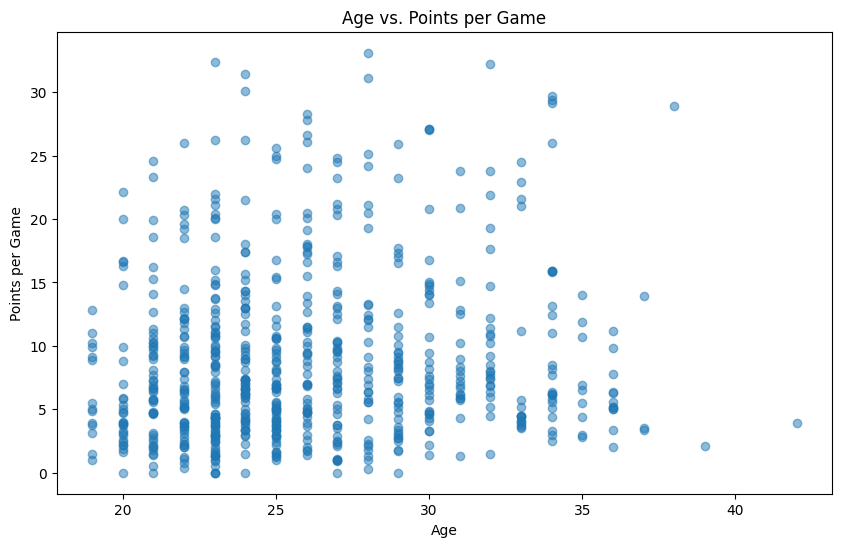

In [ ]:
import matplotlib.pyplot as plt

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(Age, Pts_per_game, alpha=0.5)

plt.xlabel('Age')
plt.ylabel('Points per Game')
plt.title('Age vs. Points per Game')

plt.show()

For my first visualization, I created a scatterplot comparing players' ages to their points scored per game. From the chart, you can see that most of the points are condensed between 20 and 30. This indicates that a majority of current NBA players are in that age range. Furthermore, the highest point per game averages are also in this younger range, implying that as players age, they begin to score less.

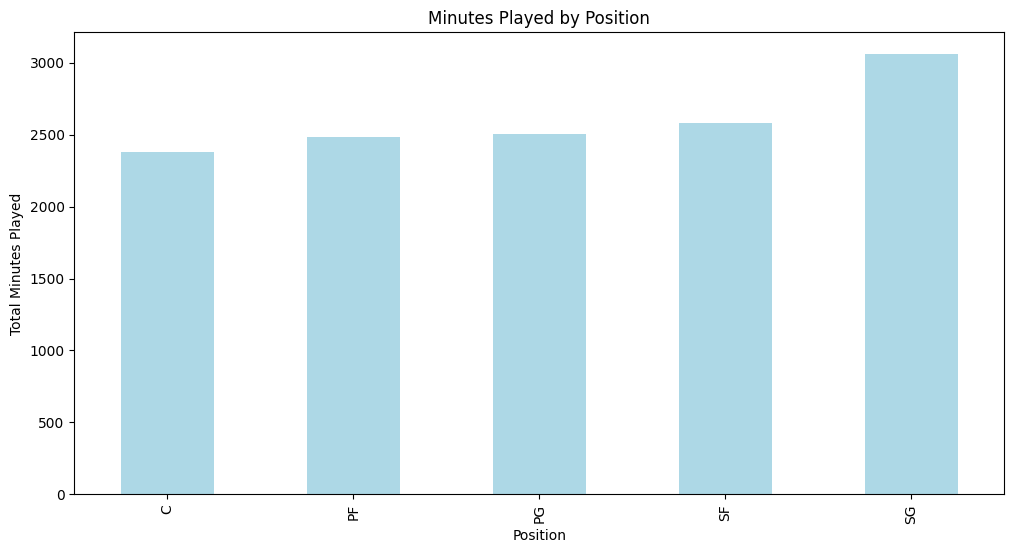

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

final_data['MP'] = pd.to_numeric(final_data['MP'], errors='coerce')  # Convert 'MP' column to numeric

# Exclude combined positions
excluded_positions = ['PF-C','PF-SF','PG-SG','Pos','SF-PF','SF-SG','SG-PG']
filtered_data = final_data[~final_data['Pos'].isin(excluded_positions)]

plt.figure(figsize=(12, 6))
position_minutes_played = filtered_data.groupby('Pos')['MP'].sum() # add up total minutes played
position_minutes_played.plot(kind='bar', color='lightblue')
plt.title('Minutes Played by Position')
plt.xlabel('Position')
plt.ylabel('Total Minutes Played')
plt.show()

For the next visual, I wanted to explore the relationship between a player's position and their playing time. To do so, I created a bar chart with each of the five positions (excluding combined ones that the original dataset contained for players that played both) and the total minutes played by players of those positions. The resulting graph depicts how shoorting guards tend to play for the most time in a game. This information is reasonable because they are also typically the highest scorers for teams.